In [ ]:
from pathlib import Path

import pandas as pd
from Bio import SeqIO
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa

In [ ]:
cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "metadata").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "metadata").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Cannot locate project root. "
        "Please run this notebook inside the project repository."
    )

FASTA_DIR = PROJECT_ROOT / "data" / "raw" / "fasta"
EXP_DIR = PROJECT_ROOT / "data" / "raw" / "experimental"
AF_DIR = PROJECT_ROOT / "data" / "raw" / "alphafold"

METADATA_FILE = PROJECT_ROOT / "metadata" / "proteins.csv"

print("Current working directory:")
print(cwd)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nFASTA directory:")
print(FASTA_DIR)

print("\nExperimental PDB directory:")
print(EXP_DIR)

print("\nAlphaFold directory:")
print(AF_DIR)

print("\nMetadata file:")
print(METADATA_FILE)

In [ ]:
required_files = [
    FASTA_DIR / "P00918.fasta",
    FASTA_DIR / "P10599.fasta",
    FASTA_DIR / "P69441.fasta",

    EXP_DIR / "2CBA.pdb",
    EXP_DIR / "1ERT.pdb",
    EXP_DIR / "4AKE.pdb",

    AF_DIR / "AF-P00918-F1-model.pdb",
    AF_DIR / "AF-P10599-F1-model.pdb",
    AF_DIR / "AF-P69441-F1-model.pdb",
]

for file_path in required_files:
    status = "OK" if file_path.exists() else "MISSING"
    print(f"{status:8} {file_path.name}")

In [ ]:
file_check = []

for file_path in required_files:
    file_check.append({
        "file": file_path.name,
        "exists": file_path.exists(),
        "size_bytes": file_path.stat().st_size if file_path.exists() else 0
    })

file_check_df = pd.DataFrame(file_check)

file_check_df

In [ ]:
assert file_check_df["exists"].all(), \
    "At least one required file is missing."

assert (file_check_df["size_bytes"] > 0).all(), \
    "At least one required file is empty."

print("All required raw files exist and are non-empty.")

In [ ]:
metadata = pd.read_csv(METADATA_FILE)

metadata

In [ ]:
metadata.info()

In [ ]:
print("Number of proteins:", len(metadata))
print("\nColumns:")
print(metadata.columns.tolist())

In [ ]:
required_metadata_columns = [
    "protein",
    "gene",
    "organism",
    "uniprot_id",
    "pdb_id",
    "experimental_chain",
    "state",
    "expected_uniprot_length"
]

missing_values = metadata[required_metadata_columns].isnull().sum()

missing_values

In [ ]:
assert len(metadata) == 3, \
    "Unexpected number of protein entries."

assert missing_values.sum() == 0, \
    "Metadata contains missing values."

print("Metadata table passed basic integrity checks.")

In [ ]:
metadata = pd.read_csv(METADATA_FILE)
metadata

In [ ]:
metadata.info()

In [ ]:
required_metadata_columns = [
    "protein",
    "gene",
    "organism",
    "uniprot_id",
    "pdb_id",
    "experimental_chain",
    "state",
    "expected_uniprot_length"
]

missing_values = metadata[required_metadata_columns].isnull().sum()

missing_values

In [ ]:
assert len(metadata) == 3, \
    "Unexpected number of protein entries."

assert missing_values.sum() == 0, \
    "Metadata contains missing values."

print("Metadata table passed basic integrity checks.")

In [ ]:
record = SeqIO.read(
    FASTA_DIR / "P00918.fasta",
    "fasta"
)

print("FASTA ID:")
print(record.id)

print("\nDescription:")
print(record.description)

print("\nSequence length:")
print(len(record.seq))

print("\nFirst 30 amino acids:")
print(record.seq[:30])

In [ ]:
record = SeqIO.read(
    FASTA_DIR / "P00918.fasta",
    "fasta"
)

print("FASTA ID:")
print(record.id)

print("\nDescription:")
print(record.description)

print("\nSequence length:")
print(len(record.seq))

print("\nFirst 30 amino acids:")
print(record.seq[:30])

In [ ]:
def inspect_fasta(uniprot_id):
    fasta_path = FASTA_DIR / f"{uniprot_id}.fasta"

    record = SeqIO.read(
        fasta_path,
        "fasta"
    )

    return {
        "uniprot_id": uniprot_id,
        "fasta_id": record.id,
        "fasta_description": record.description,
        "fasta_length": len(record.seq),
        "sequence": str(record.seq)
    }

In [ ]:
test_result = inspect_fasta("P00918")

test_result

In [ ]:
def inspect_fasta(uniprot_id):
    ...

In [ ]:
test_result = inspect_fasta("P00918")
test_result

In [ ]:
def inspect_fasta(uniprot_id):
    fasta_path = FASTA_DIR / f"{uniprot_id}.fasta"

    record = SeqIO.read(
        fasta_path,
        "fasta"
    )

    return {
        "uniprot_id": uniprot_id,
        "fasta_id": record.id,
        "fasta_description": record.description,
        "fasta_length": len(record.seq),
        "sequence": str(record.seq)
    }

In [ ]:
test_result = inspect_fasta("P00918")

test_result

In [ ]:
fasta_results = []

for uniprot_id in metadata["uniprot_id"]:
    result = inspect_fasta(uniprot_id)
    fasta_results.append(result)

fasta_df = pd.DataFrame(fasta_results)

fasta_df[
    [
        "uniprot_id",
        "fasta_id",
        "fasta_length"
    ]
]

In [ ]:
fasta_check = metadata[
    [
        "protein",
        "uniprot_id",
        "expected_uniprot_length"
    ]
].merge(
    fasta_df[
        [
            "uniprot_id",
            "fasta_length"
        ]
    ],
    on="uniprot_id"
)

fasta_check["length_match"] = (
    fasta_check["expected_uniprot_length"]
    ==
    fasta_check["fasta_length"]
)

fasta_check

In [ ]:
assert fasta_check["length_match"].all(), \
    "At least one FASTA sequence length does not match metadata."

print("All FASTA sequence lengths match expected UniProt lengths.")

In [ ]:
parser = PDBParser(QUIET=True)

In [ ]:
structure = parser.get_structure(
    "2CBA",
    EXP_DIR / "2CBA.pdb"
)

structure

In [ ]:
models = list(structure)

print("Number of models:", len(models))

In [ ]:
model = structure[0]

model

In [ ]:
chains = list(model)

print("Chains:")
for chain in chains:
    print(chain.id)

In [ ]:
chain = model["A"]

chain

In [ ]:
residues = list(chain)

print("Total residue-like records:", len(residues))

In [ ]:
amino_acid_residues = [
    residue
    for residue in chain
    if is_aa(residue, standard=True)
]

print(
    "Standard amino-acid residues:",
    len(amino_acid_residues)
)

In [ ]:
for residue in amino_acid_residues[:5]:
    print(
        residue.get_resname(),
        residue.id
    )

In [ ]:
ca_residues = [
    residue
    for residue in amino_acid_residues
    if "CA" in residue
]

print("Amino-acid residues:", len(amino_acid_residues))
print("Residues containing C-alpha:", len(ca_residues))

In [ ]:
print("First 10 modeled residues:")

for residue in amino_acid_residues[:10]:
    print(
        residue.get_resname(),
        residue.id
    )

print("\nLast 10 modeled residues:")

for residue in amino_acid_residues[-10:]:
    print(
        residue.get_resname(),
        residue.id
    )

In [ ]:
def inspect_structure(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]

    available_chains = [
        chain.id
        for chain in model
    ]

    if chain_id not in available_chains:
        raise ValueError(
            f"Chain {chain_id} not found in {pdb_path.name}. "
            f"Available chains: {available_chains}"
        )

    chain = model[chain_id]

    amino_acid_residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    ca_residues = [
        residue
        for residue in amino_acid_residues
        if "CA" in residue
    ]

    return {
        "file": pdb_path.name,
        "chain": chain_id,
        "available_chains": ",".join(available_chains),
        "aa_residue_count": len(amino_acid_residues),
        "ca_residue_count": len(ca_residues)
    }

In [ ]:
test_structure = inspect_structure(
    EXP_DIR / "2CBA.pdb",
    "A"
)

test_structure

In [ ]:
def inspect_structure(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]

    available_chains = [
        chain.id
        for chain in model
    ]

    if chain_id not in available_chains:
        raise ValueError(
            f"Chain {chain_id} not found in {pdb_path.name}. "
            f"Available chains: {available_chains}"
        )

    chain = model[chain_id]

    amino_acid_residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    ca_residues = [
        residue
        for residue in amino_acid_residues
        if "CA" in residue
    ]

    return {
        "file": pdb_path.name,
        "chain": chain_id,
        "available_chains": ",".join(available_chains),
        "aa_residue_count": len(amino_acid_residues),
        "ca_residue_count": len(ca_residues)
    }

In [ ]:
test_structure = inspect_structure(
    EXP_DIR / "2CBA.pdb",
    "A"
)

test_structure

In [ ]:
def inspect_structure(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]

    available_chains = [
        chain.id
        for chain in model
    ]

    if chain_id not in available_chains:
        raise ValueError(
            f"Chain {chain_id} not found in {pdb_path.name}. "
            f"Available chains: {available_chains}"
        )

    chain = model[chain_id]

    amino_acid_residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    ca_residues = [
        residue
        for residue in amino_acid_residues
        if "CA" in residue
    ]

    return {
        "file": pdb_path.name,
        "chain": chain_id,
        "available_chains": ",".join(available_chains),
        "aa_residue_count": len(amino_acid_residues),
        "ca_residue_count": len(ca_residues)
    }

In [ ]:
from pathlib import Path

import pandas as pd
from Bio import SeqIO
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa

In [ ]:
cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "metadata").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "metadata").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Cannot locate project root. "
        "Please run this notebook inside the project repository."
    )

FASTA_DIR = PROJECT_ROOT / "data" / "raw" / "fasta"
EXP_DIR = PROJECT_ROOT / "data" / "raw" / "experimental"
AF_DIR = PROJECT_ROOT / "data" / "raw" / "alphafold"

METADATA_FILE = PROJECT_ROOT / "metadata" / "proteins.csv"

print("Project root:", PROJECT_ROOT)
print("Experimental PDB directory:", EXP_DIR)

In [ ]:
parser = PDBParser(QUIET=True)

In [ ]:
def inspect_structure(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]

    available_chains = [
        chain.id
        for chain in model
    ]

    if chain_id not in available_chains:
        raise ValueError(
            f"Chain {chain_id} not found in {pdb_path.name}. "
            f"Available chains: {available_chains}"
        )

    chain = model[chain_id]

    amino_acid_residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    ca_residues = [
        residue
        for residue in amino_acid_residues
        if "CA" in residue
    ]

    return {
        "file": pdb_path.name,
        "chain": chain_id,
        "available_chains": ",".join(available_chains),
        "aa_residue_count": len(amino_acid_residues),
        "ca_residue_count": len(ca_residues)
    }

In [ ]:
test_structure = inspect_structure(
    EXP_DIR / "2CBA.pdb",
    "A"
)

test_structure

In [ ]:
metadata = pd.read_csv(METADATA_FILE)
metadata

In [ ]:
parser = PDBParser(QUIET=True)

In [ ]:
def inspect_structure(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]

    available_chains = [
        chain.id
        for chain in model
    ]

    if chain_id not in available_chains:
        raise ValueError(
            f"Chain {chain_id} not found in {pdb_path.name}. "
            f"Available chains: {available_chains}"
        )

    chain = model[chain_id]

    amino_acid_residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    ca_residues = [
        residue
        for residue in amino_acid_residues
        if "CA" in residue
    ]

    return {
        "file": pdb_path.name,
        "chain": chain_id,
        "available_chains": ",".join(available_chains),
        "aa_residue_count": len(amino_acid_residues),
        "ca_residue_count": len(ca_residues)
    }

In [ ]:
experimental_results = []

for _, row in metadata.iterrows():

    pdb_path = (
        EXP_DIR /
        f"{row['pdb_id']}.pdb"
    )

    result = inspect_structure(
        pdb_path,
        row["experimental_chain"]
    )

    result["protein"] = row["protein"]
    result["uniprot_id"] = row["uniprot_id"]
    result["pdb_id"] = row["pdb_id"]

    experimental_results.append(result)

experimental_df = pd.DataFrame(experimental_results)

experimental_df[
    [
        "protein",
        "uniprot_id",
        "pdb_id",
        "chain",
        "available_chains",
        "aa_residue_count",
        "ca_residue_count"
    ]
]

In [ ]:
experimental_df["all_aa_have_ca"] = (
    experimental_df["aa_residue_count"]
    ==
    experimental_df["ca_residue_count"]
)

experimental_df[
    [
        "protein",
        "aa_residue_count",
        "ca_residue_count",
        "all_aa_have_ca"
    ]
]

In [ ]:
assert experimental_df["all_aa_have_ca"].all(), \
    "At least one experimental structure contains amino-acid residues without C-alpha."

print("All modeled experimental amino-acid residues contain C-alpha atoms.")

In [ ]:
alphafold_results = []

for _, row in metadata.iterrows():

    uniprot_id = row["uniprot_id"]

    af_path = (
        AF_DIR /
        f"AF-{uniprot_id}-F1-model.pdb"
    )

    result = inspect_structure(
        af_path,
        "A"
    )

    result["protein"] = row["protein"]
    result["uniprot_id"] = uniprot_id

    alphafold_results.append(result)

alphafold_df = pd.DataFrame(alphafold_results)

alphafold_df[
    [
        "protein",
        "uniprot_id",
        "chain",
        "aa_residue_count",
        "ca_residue_count"
    ]
]

In [ ]:
alphafold_df["all_aa_have_ca"] = (
    alphafold_df["aa_residue_count"]
    ==
    alphafold_df["ca_residue_count"]
)

alphafold_df[
    [
        "protein",
        "aa_residue_count",
        "ca_residue_count",
        "all_aa_have_ca"
    ]
]

In [ ]:
assert alphafold_df["all_aa_have_ca"].all(), \
    "At least one AlphaFold model contains amino-acid residues without C-alpha."

print("All AlphaFold amino-acid residues contain C-alpha atoms.")

In [ ]:
def inspect_fasta(uniprot_id):
    fasta_path = FASTA_DIR / f"{uniprot_id}.fasta"

    record = SeqIO.read(
        fasta_path,
        "fasta"
    )

    return {
        "uniprot_id": uniprot_id,
        "fasta_id": record.id,
        "fasta_description": record.description,
        "fasta_length": len(record.seq),
        "sequence": str(record.seq)
    }

In [ ]:
fasta_results = []

for uniprot_id in metadata["uniprot_id"]:
    result = inspect_fasta(uniprot_id)
    fasta_results.append(result)

fasta_df = pd.DataFrame(fasta_results)

fasta_df[
    [
        "uniprot_id",
        "fasta_id",
        "fasta_length"
    ]
]

In [ ]:
print(fasta_df.columns.tolist())

In [ ]:
structure_summary = (
    metadata[
        [
            "protein",
            "uniprot_id",
            "pdb_id",
            "expected_uniprot_length"
        ]
    ]
    .merge(
        fasta_df[
            [
                "uniprot_id",
                "fasta_length"
            ]
        ],
        on="uniprot_id"
    )
    .merge(
        experimental_df[
            [
                "uniprot_id",
                "aa_residue_count",
                "ca_residue_count"
            ]
        ].rename(
            columns={
                "aa_residue_count": "experimental_residues",
                "ca_residue_count": "experimental_ca_residues"
            }
        ),
        on="uniprot_id"
    )
    .merge(
        alphafold_df[
            [
                "uniprot_id",
                "aa_residue_count",
                "ca_residue_count"
            ]
        ].rename(
            columns={
                "aa_residue_count": "alphafold_residues",
                "ca_residue_count": "alphafold_ca_residues"
            }
        ),
        on="uniprot_id"
    )
)

structure_summary

In [ ]:
structure_summary[
    [
        "protein",
        "fasta_length",
        "experimental_residues",
        "experimental_ca_residues",
        "alphafold_residues",
        "alphafold_ca_residues"
    ]
]

In [ ]:
from Bio.Align import PairwiseAligner
from Bio.SeqUtils import seq1

In [ ]:
def extract_chain_sequence(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]
    chain = model[chain_id]

    residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    sequence = "".join(
        seq1(residue.get_resname())
        for residue in residues
    )

    return residues, sequence

In [ ]:
ca2_pdb_residues, ca2_pdb_sequence = extract_chain_sequence(
    EXP_DIR / "2CBA.pdb",
    "A"
)

print("Number of modeled residues:", len(ca2_pdb_residues))
print("PDB-derived sequence length:", len(ca2_pdb_sequence))

print("\nFirst 30 amino acids:")
print(ca2_pdb_sequence[:30])

In [ ]:
ca2_uniprot_sequence = fasta_df.loc[
    fasta_df["uniprot_id"] == "P00918",
    "sequence"
].iloc[0]

print("UniProt sequence length:", len(ca2_uniprot_sequence))

In [ ]:
aligner = PairwiseAligner()

aligner.mode = "global"

aligner.match_score = 2
aligner.mismatch_score = -1

aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

In [ ]:
alignments = aligner.align(
    ca2_uniprot_sequence,
    ca2_pdb_sequence
)

best_alignment = alignments[0]

print(best_alignment)

In [ ]:
best_alignment.aligned

In [ ]:
def build_residue_mapping(
    uniprot_id,
    uniprot_sequence,
    pdb_path,
    chain_id
):
    pdb_residues, pdb_sequence = extract_chain_sequence(
        pdb_path,
        chain_id
    )

    alignments = aligner.align(
        uniprot_sequence,
        pdb_sequence
    )

    best_alignment = alignments[0]

    mapping_rows = []

    uniprot_blocks = best_alignment.aligned[0]
    pdb_blocks = best_alignment.aligned[1]

    for (u_start, u_end), (p_start, p_end) in zip(
        uniprot_blocks,
        pdb_blocks
    ):

        block_length = min(
            u_end - u_start,
            p_end - p_start
        )

        for offset in range(block_length):

            u_index = u_start + offset
            p_index = p_start + offset

            residue = pdb_residues[p_index]

            mapping_rows.append({
                "uniprot_id": uniprot_id,

                "uniprot_position": u_index + 1,
                "uniprot_aa": uniprot_sequence[u_index],

                "pdb_sequence_index": p_index + 1,

                "pdb_residue_number": residue.id[1],

                "pdb_insertion_code":
                    residue.id[2].strip(),

                "pdb_aa": pdb_sequence[p_index],

                "aa_match":
                    uniprot_sequence[u_index]
                    ==
                    pdb_sequence[p_index]
            })

    mapping_df = pd.DataFrame(mapping_rows)

    return mapping_df, best_alignment

In [ ]:
ca2_mapping, ca2_alignment = build_residue_mapping(
    "P00918",
    ca2_uniprot_sequence,
    EXP_DIR / "2CBA.pdb",
    "A"
)

ca2_mapping.head(10)

In [ ]:
print("Mapped residues:", len(ca2_mapping))
print(
    "AA mismatches:",
    (~ca2_mapping["aa_match"]).sum()
)

In [ ]:
mapped_positions = set(
    ca2_mapping["uniprot_position"]
)

all_positions = set(
    range(
        1,
        len(ca2_uniprot_sequence) + 1
    )
)

unmapped_positions = sorted(
    all_positions - mapped_positions
)

print("Unmapped UniProt positions:")
print(unmapped_positions)

In [ ]:
structure_summary[
    [
        "protein",
        "fasta_length",
        "experimental_residues",
        "experimental_ca_residues",
        "alphafold_residues",
        "alphafold_ca_residues"
    ]
]

In [ ]:
from Bio.Align import PairwiseAligner
from Bio.SeqUtils import seq1

In [ ]:
def extract_chain_sequence(pdb_path, chain_id):
    structure = parser.get_structure(
        pdb_path.stem,
        pdb_path
    )

    model = structure[0]
    chain = model[chain_id]

    residues = [
        residue
        for residue in chain
        if is_aa(residue, standard=True)
    ]

    sequence = "".join(
        seq1(residue.get_resname())
        for residue in residues
    )

    return residues, sequence

In [ ]:
ca2_pdb_residues, ca2_pdb_sequence = extract_chain_sequence(
    EXP_DIR / "2CBA.pdb",
    "A"
)

print("Number of PDB residues:", len(ca2_pdb_residues))
print("PDB-derived sequence length:", len(ca2_pdb_sequence))

print("\nFirst 30 PDB-derived amino acids:")
print(ca2_pdb_sequence[:30])

In [ ]:
ca2_uniprot_sequence = fasta_df.loc[
    fasta_df["uniprot_id"] == "P00918",
    "sequence"
].iloc[0]

print("UniProt sequence length:", len(ca2_uniprot_sequence))

print("\nFirst 30 UniProt amino acids:")
print(ca2_uniprot_sequence[:30])

In [ ]:
aligner = PairwiseAligner()

aligner.mode = "global"

aligner.match_score = 2
aligner.mismatch_score = -1

aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

In [ ]:
alignments = aligner.align(
    ca2_uniprot_sequence,
    ca2_pdb_sequence
)

best_alignment = alignments[0]

print(best_alignment)

In [ ]:
best_alignment.aligned

In [ ]:
print(best_alignment)

In [ ]:
best_alignment.aligned

In [ ]:
print("First 5 PDB residues:")

for residue in ca2_pdb_residues[:5]:
    print(
        residue.get_resname(),
        residue.id
    )

print("\nLast 5 PDB residues:")

for residue in ca2_pdb_residues[-5:]:
    print(
        residue.get_resname(),
        residue.id
    )

In [ ]:
def build_residue_mapping(
    uniprot_id,
    uniprot_sequence,
    pdb_path,
    chain_id
):
    pdb_residues, pdb_sequence = extract_chain_sequence(
        pdb_path,
        chain_id
    )

    alignments = aligner.align(
        uniprot_sequence,
        pdb_sequence
    )

    best_alignment = alignments[0]

    mapping_rows = []

    uniprot_blocks = best_alignment.aligned[0]
    pdb_blocks = best_alignment.aligned[1]

    for (u_start, u_end), (p_start, p_end) in zip(
        uniprot_blocks,
        pdb_blocks
    ):

        for u_index, p_index in zip(
            range(u_start, u_end),
            range(p_start, p_end)
        ):

            residue = pdb_residues[p_index]

            mapping_rows.append({
                "uniprot_id": uniprot_id,
                "uniprot_position": u_index + 1,
                "uniprot_aa": uniprot_sequence[u_index],
                "pdb_sequence_index": p_index + 1,
                "pdb_residue_number": residue.id[1],
                "pdb_insertion_code": residue.id[2].strip(),
                "pdb_aa": pdb_sequence[p_index],
                "aa_match": (
                    uniprot_sequence[u_index]
                    ==
                    pdb_sequence[p_index]
                )
            })

    mapping_df = pd.DataFrame(mapping_rows)

    return mapping_df, best_alignment

In [ ]:
ca2_mapping, ca2_alignment = build_residue_mapping(
    "P00918",
    ca2_uniprot_sequence,
    EXP_DIR / "2CBA.pdb",
    "A"
)

ca2_mapping.head(10)

In [ ]:
mapped_positions = set(
    ca2_mapping["uniprot_position"]
)

all_positions = set(
    range(1, len(ca2_uniprot_sequence) + 1)
)

unmapped_positions = sorted(
    all_positions - mapped_positions
)

print("Mapped residues:", len(ca2_mapping))
print("Unmapped UniProt positions:", unmapped_positions)
print(
    "AA mismatches:",
    (~ca2_mapping["aa_match"]).sum()
)

In [ ]:
best_alignment.aligned

In [ ]:
print("First 5 PDB residues:")

for residue in ca2_pdb_residues[:5]:
    print(
        residue.get_resname(),
        residue.id
    )

print("\nLast 5 PDB residues:")

for residue in ca2_pdb_residues[-5:]:
    print(
        residue.get_resname(),
        residue.id
    )

In [ ]:
pdb_residue_numbers = [
    residue.id[1]
    for residue in ca2_pdb_residues
]

numbering_gaps = []

for previous, current in zip(
    pdb_residue_numbers[:-1],
    pdb_residue_numbers[1:]
):
    if current - previous != 1:
        numbering_gaps.append(
            (previous, current)
        )

print("PDB residue numbering gaps:")
print(numbering_gaps)

In [ ]:
def build_residue_mapping(
    uniprot_id,
    uniprot_sequence,
    pdb_path,
    chain_id
):
    pdb_residues, pdb_sequence = extract_chain_sequence(
        pdb_path,
        chain_id
    )

    alignments = aligner.align(
        uniprot_sequence,
        pdb_sequence
    )

    best_alignment = alignments[0]

    mapping_rows = []

    uniprot_blocks = best_alignment.aligned[0]
    pdb_blocks = best_alignment.aligned[1]

    for (u_start, u_end), (p_start, p_end) in zip(
        uniprot_blocks,
        pdb_blocks
    ):

        for u_index, p_index in zip(
            range(u_start, u_end),
            range(p_start, p_end)
        ):

            residue = pdb_residues[p_index]

            mapping_rows.append({
                "uniprot_id": uniprot_id,
                "uniprot_position": u_index + 1,
                "uniprot_aa": uniprot_sequence[u_index],

                "pdb_sequence_index": p_index + 1,
                "pdb_residue_number": residue.id[1],
                "pdb_insertion_code": residue.id[2].strip(),

                "pdb_aa": pdb_sequence[p_index],

                "aa_match": (
                    uniprot_sequence[u_index]
                    ==
                    pdb_sequence[p_index]
                )
            })

    mapping_df = pd.DataFrame(mapping_rows)

    return mapping_df, best_alignment

In [ ]:
ca2_mapping, ca2_alignment = build_residue_mapping(
    "P00918",
    ca2_uniprot_sequence,
    EXP_DIR / "2CBA.pdb",
    "A"
)

In [ ]:
mapped_positions = set(
    ca2_mapping["uniprot_position"]
)

all_positions = set(
    range(
        1,
        len(ca2_uniprot_sequence) + 1
    )
)

unmapped_positions = sorted(
    all_positions - mapped_positions
)

print("Mapped residues:", len(ca2_mapping))

print(
    "Unmapped UniProt positions:",
    unmapped_positions
)

print(
    "AA mismatches:",
    (~ca2_mapping["aa_match"]).sum()
)

In [ ]:
print(numbering_gaps)

In [ ]:
ca2_mapping.head(10)
ca2_mapping.tail(10)

In [ ]:
print("Mapped residues:", len(ca2_mapping))
print("Unmapped UniProt positions:", unmapped_positions)
print("AA mismatches:", (~ca2_mapping["aa_match"]).sum())

In [ ]:
all_mappings = {}
all_alignments = {}

for _, row in metadata.iterrows():

    uniprot_id = row["uniprot_id"]
    pdb_id = row["pdb_id"]
    chain_id = row["experimental_chain"]

    uniprot_sequence = fasta_df.loc[
        fasta_df["uniprot_id"] == uniprot_id,
        "sequence"
    ].iloc[0]

    mapping_df, alignment = build_residue_mapping(
        uniprot_id,
        uniprot_sequence,
        EXP_DIR / f"{pdb_id}.pdb",
        chain_id
    )

    all_mappings[uniprot_id] = mapping_df
    all_alignments[uniprot_id] = alignment

    print(
        f"{uniprot_id} / {pdb_id}: "
        f"{len(mapping_df)} mapped residues, "
        f"{(~mapping_df['aa_match']).sum()} mismatches"
    )

In [ ]:
mapping_summary = []

for _, row in metadata.iterrows():

    uniprot_id = row["uniprot_id"]
    mapping_df = all_mappings[uniprot_id]

    canonical_length = int(
        row["expected_uniprot_length"]
    )

    mapped_positions = set(
        mapping_df["uniprot_position"]
    )

    all_positions = set(
        range(1, canonical_length + 1)
    )

    unmapped_positions = sorted(
        all_positions - mapped_positions
    )

    mismatch_count = int(
        (~mapping_df["aa_match"]).sum()
    )

    mapping_summary.append({
        "protein": row["protein"],
        "uniprot_id": uniprot_id,
        "pdb_id": row["pdb_id"],
        "canonical_length": canonical_length,
        "mapped_residues": len(mapping_df),
        "unmapped_count": len(unmapped_positions),
        "unmapped_positions": (
            ",".join(map(str, unmapped_positions))
            if unmapped_positions
            else ""
        ),
        "aa_mismatches": mismatch_count
    })

mapping_summary_df = pd.DataFrame(
    mapping_summary
)

mapping_summary_df

In [ ]:
for uniprot_id, mapping_df in all_mappings.items():

    assert mapping_df[
        "uniprot_position"
    ].is_unique, \
        f"Duplicate UniProt positions detected for {uniprot_id}"

    print(
        uniprot_id,
        "UniProt mapping positions are unique."
    )

In [ ]:
gene_name_map = {
    "P00918": "CA2",
    "P10599": "TXN",
    "P69441": "ADK"
}

for uniprot_id, mapping_df in all_mappings.items():

    gene_name = gene_name_map[
        uniprot_id
    ]

    output_file = (
        PROJECT_ROOT /
        "data" /
        "processed" /
        f"{gene_name}_residue_mapping.csv"
    )

    mapping_df.to_csv(
        output_file,
        index=False
    )

    print(
        "Saved:",
        output_file.name
    )

In [ ]:
mapping_summary_file = (
    PROJECT_ROOT /
    "results" /
    "tables" /
    "mapping_summary.csv"
)

mapping_summary_df.to_csv(
    mapping_summary_file,
    index=False
)

print(
    "Saved:",
    mapping_summary_file
)

In [ ]:
required_objects = [
    "metadata",
    "fasta_df",
    "build_residue_mapping",
    "EXP_DIR",
    "PROJECT_ROOT"
]

for name in required_objects:
    print(name, name in globals())

In [ ]:
all_mappings = {}
all_alignments = {}

for _, row in metadata.iterrows():

    uniprot_id = row["uniprot_id"]
    pdb_id = row["pdb_id"]
    chain_id = row["experimental_chain"]

    uniprot_sequence = fasta_df.loc[
        fasta_df["uniprot_id"] == uniprot_id,
        "sequence"
    ].iloc[0]

    mapping_df, alignment = build_residue_mapping(
        uniprot_id,
        uniprot_sequence,
        EXP_DIR / f"{pdb_id}.pdb",
        chain_id
    )

    all_mappings[uniprot_id] = mapping_df
    all_alignments[uniprot_id] = alignment

    print(
        f"{uniprot_id} / {pdb_id}: "
        f"{len(mapping_df)} mapped residues, "
        f"{(~mapping_df['aa_match']).sum()} mismatches"
    )

In [ ]:
print(all_mappings.keys())

In [ ]:
len(all_mappings["P00918"])

In [ ]:
mapping_summary = []

for _, row in metadata.iterrows():

    uniprot_id = row["uniprot_id"]
    mapping_df = all_mappings[uniprot_id]

    canonical_length = int(
        row["expected_uniprot_length"]
    )

    mapped_positions = set(
        mapping_df["uniprot_position"]
    )

    all_positions = set(
        range(1, canonical_length + 1)
    )

    unmapped_positions = sorted(
        all_positions - mapped_positions
    )

    mismatch_count = int(
        (~mapping_df["aa_match"]).sum()
    )

    mapping_summary.append({
        "protein": row["protein"],
        "uniprot_id": uniprot_id,
        "pdb_id": row["pdb_id"],
        "canonical_length": canonical_length,
        "mapped_residues": len(mapping_df),
        "unmapped_count": len(unmapped_positions),
        "unmapped_positions": (
            ",".join(map(str, unmapped_positions))
            if unmapped_positions
            else ""
        ),
        "aa_mismatches": mismatch_count
    })

mapping_summary_df = pd.DataFrame(
    mapping_summary
)

mapping_summary_df

In [ ]:
assert (
    mapping_summary_df["aa_mismatches"] == 0
).all(), \
    "At least one mapping contains amino-acid mismatches."

print("All mapped residues have matching amino-acid identities.")

In [ ]:
for uniprot_id, mapping_df in all_mappings.items():

    assert mapping_df[
        "uniprot_position"
    ].is_unique, \
        f"Duplicate UniProt positions detected for {uniprot_id}"

    print(
        uniprot_id,
        "UniProt mapping positions are unique."
    )

In [ ]:
gene_name_map = {
    "P00918": "CA2",
    "P10599": "TXN",
    "P69441": "ADK"
}

In [ ]:
for uniprot_id, mapping_df in all_mappings.items():

    gene_name = gene_name_map[uniprot_id]

    output_file = (
        PROJECT_ROOT /
        "data" /
        "processed" /
        f"{gene_name}_residue_mapping.csv"
    )

    mapping_df.to_csv(
        output_file,
        index=False
    )

    print("Saved:", output_file.name)

In [ ]:
list(
    (PROJECT_ROOT / "data" / "processed").glob("*.csv")
)

In [ ]:
mapping_summary_file = (
    PROJECT_ROOT /
    "result" /
    "table" /
    "mapping_summary.csv"
)

mapping_summary_df.to_csv(
    mapping,
    index=False
)

print("Saved:", mapping_summary_file)

In [ ]:
objects_to_check = [
    "PROJECT_ROOT",
    "mapping_summary_df",
    "all_mappings"
]

for name in objects_to_check:
    print(name, name in globals())

In [ ]:
objects_to_check = [
    "PROJECT_ROOT",
    "mapping_summary_df",
    "all_mappings"
]

for name in objects_to_check:
    print(name, name in globals())

In [ ]:
objects_to_check = [
    "PROJECT_ROOT",
    "metadata",
    "fasta_df",
    "experimental_df",
    "alphafold_df",
    "all_mappings",
    "mapping_summary_df"
]

for name in objects_to_check:
    print(name, name in globals())

In [ ]:
from pathlib import Path

import pandas as pd
from Bio import SeqIO
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa

In [ ]:
from pathlib import Path
import pandas as pd
from Bio import SeqIO
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa

print("pandas:", pd.__version__)
print("Environment OK")

In [ ]:
objects_to_check = [
    "PROJECT_ROOT",
    "metadata",
    "fasta_df",
    "experimental_df",
    "alphafold_df",
    "all_mappings",
    "mapping_summary_df"
]

for name in objects_to_check:
    print(name, name in globals())

In [ ]:
print("TEST")

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

print("Python:", sys.version)
print("Executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Executable: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\.venv313\Scripts\python.exe
pandas: 3.0.6
numpy: 2.5.3


In [2]:
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Cannot locate project root.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "tables"

print(PROJECT_ROOT)

C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis


In [3]:
all_mappings = {
    "P00918": pd.read_csv(PROCESSED_DIR / "CA2_residue_mapping.csv"),
    "P10599": pd.read_csv(PROCESSED_DIR / "TXN_residue_mapping.csv"),
    "P69441": pd.read_csv(PROCESSED_DIR / "ADK_residue_mapping.csv"),
}

for uniprot_id, mapping_df in all_mappings.items():
    print(
        uniprot_id,
        "mapped =", len(mapping_df),
        "mismatches =", (~mapping_df["aa_match"]).sum()
    )

P00918 mapped = 258 mismatches = 0
P10599 mapped = 105 mismatches = 0
P69441 mapped = 214 mismatches = 0


In [4]:
metadata = pd.read_csv(
    PROJECT_ROOT / "metadata" / "proteins.csv"
)

mapping_summary = []

for _, row in metadata.iterrows():
    uniprot_id = row["uniprot_id"]
    mapping_df = all_mappings[uniprot_id]

    canonical_length = int(row["expected_uniprot_length"])

    mapped_positions = set(mapping_df["uniprot_position"])
    all_positions = set(range(1, canonical_length + 1))

    unmapped_positions = sorted(
        all_positions - mapped_positions
    )

    mismatch_count = int(
        (~mapping_df["aa_match"]).sum()
    )

    mapping_summary.append({
        "protein": row["protein"],
        "uniprot_id": uniprot_id,
        "pdb_id": row["pdb_id"],
        "canonical_length": canonical_length,
        "mapped_residues": len(mapping_df),
        "unmapped_count": len(unmapped_positions),
        "unmapped_positions": ",".join(
            map(str, unmapped_positions)
        ),
        "aa_mismatches": mismatch_count
    })

mapping_summary_df = pd.DataFrame(mapping_summary)

mapping_summary_df

,protein,uniprot_id,pdb_id,canonical_length,mapped_residues,unmapped_count,unmapped_positions,aa_mismatches
0,Carbonic anhydrase II,P00918,2CBA,260,258,2,"1,2",0
1,Thioredoxin,P10599,1ERT,105,105,0,,0
2,Adenylate kinase,P69441,4AKE,214,214,0,,0


In [5]:
mapping_summary_file = (
    RESULTS_DIR /
    "mapping_summary.csv"
)

mapping_summary_df.to_csv(
    mapping_summary_file,
    index=False
)

print("Saved:", mapping_summary_file)
print("Exists:", mapping_summary_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\mapping_summary.csv
Exists: True


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Cannot locate project root.")

EXP_DIR = PROJECT_ROOT / "data" / "raw" / "experimental"
AF_DIR = PROJECT_ROOT / "data" / "raw" / "alphafold"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis


In [2]:
def read_ca_atoms(pdb_path, chain_id=None):
    rows = []

    with open(pdb_path, "r", encoding="utf-8", errors="replace") as handle:
        for line in handle:

            if not line.startswith("ATOM"):
                continue

            atom_name = line[12:16].strip()
            altloc = line[16].strip()
            chain = line[21].strip()

            if atom_name != "CA":
                continue

            if altloc not in ("", "A"):
                continue

            if chain_id is not None and chain != chain_id:
                continue

            rows.append({
                "residue_name": line[17:20].strip(),
                "chain": chain,
                "residue_number": int(line[22:26]),
                "insertion_code": line[26].strip(),
                "x": float(line[30:38]),
                "y": float(line[38:46]),
                "z": float(line[46:54]),
                "occupancy": float(line[54:60]),
                "bfactor": float(line[60:66])
            })

    ca_df = pd.DataFrame(rows)

    if ca_df.empty:
        raise ValueError(
            f"No CA atoms found in {pdb_path.name}"
        )

    return ca_df

In [3]:
exp_ca2 = read_ca_atoms(
    EXP_DIR / "2CBA.pdb",
    chain_id="A"
)

af_ca2 = read_ca_atoms(
    AF_DIR / "AF-P00918-F1-model.pdb",
    chain_id="A"
)

print("Experimental 2CBA Cα count:", len(exp_ca2))
print("AlphaFold CA2 Cα count:", len(af_ca2))

print()
print(
    "Experimental residue number range:",
    exp_ca2["residue_number"].min(),
    "to",
    exp_ca2["residue_number"].max()
)

print(
    "AlphaFold residue number range:",
    af_ca2["residue_number"].min(),
    "to",
    af_ca2["residue_number"].max()
)

print()
print(
    "AlphaFold B-factor/pLDDT range:",
    af_ca2["bfactor"].min(),
    "to",
    af_ca2["bfactor"].max()
)

Experimental 2CBA Cα count: 258
AlphaFold CA2 Cα count: 260

Experimental residue number range: 3 to 261
AlphaFold residue number range: 1 to 260

AlphaFold B-factor/pLDDT range: 35.34 to 98.94


In [4]:
display(exp_ca2.head(10))
display(af_ca2.head(10))

,residue_name,chain,residue_number,insertion_code,x,y,z,occupancy,bfactor
0,HIS,A,3,,13.714,-0.741,9.013,0.5,25.54
1,HIS,A,4,,9.989,0.244,8.985,1.0,21.11
2,TRP,A,5,,7.704,-1.519,11.429,1.0,13.74
3,GLY,A,6,,5.389,-4.309,10.476,1.0,10.51
4,TYR,A,7,,4.377,-7.768,11.641,1.0,11.88
5,GLY,A,8,,7.285,-9.837,10.303,1.0,18.31
6,LYS,A,9,,10.036,-11.614,12.218,1.0,22.88
7,HIS,A,10,,12.463,-8.762,11.679,1.0,19.11
8,ASN,A,11,,10.176,-5.737,12.225,1.0,13.76
9,GLY,A,12,,7.329,-7.156,14.327,1.0,11.93


,residue_name,chain,residue_number,insertion_code,x,y,z,occupancy,bfactor
0,MET,A,1,,1.296,-17.076,-18.606,1.0,35.34
1,SER,A,2,,3.389,-14.293,-17.000,1.0,53.88
2,HIS,A,3,,1.097,-11.298,-17.580,1.0,69.06
3,HIS,A,4,,3.512,-8.473,-18.454,1.0,85.00
4,TRP,A,5,,2.387,-5.098,-17.045,1.0,95.12
5,GLY,A,6,,4.188,-1.808,-16.306,1.0,95.81
6,TYR,A,7,,3.781,1.993,-16.607,1.0,96.69
7,GLY,A,8,,5.093,2.349,-20.199,1.0,93.56
8,LYS,A,9,,3.077,3.331,-23.328,1.0,92.69
9,HIS,A,10,,2.275,-0.321,-24.298,1.0,93.94


In [5]:
ca2_mapping = pd.read_csv(
    PROCESSED_DIR / "CA2_residue_mapping.csv"
)

print("Mapping rows:", len(ca2_mapping))

display(ca2_mapping.head())

Mapping rows: 258


,uniprot_id,uniprot_position,uniprot_aa,pdb_sequence_index,pdb_residue_number,pdb_insertion_code,pdb_aa,aa_match
0,P00918,3,H,1,3,NaN,H,True
1,P00918,4,H,2,4,NaN,H,True
2,P00918,5,W,3,5,NaN,W,True
3,P00918,6,G,4,6,NaN,G,True
4,P00918,7,Y,5,7,NaN,Y,True


In [6]:
exp_coords = exp_ca2[
    [
        "residue_name",
        "residue_number",
        "insertion_code",
        "x",
        "y",
        "z"
    ]
].copy()

exp_coords = exp_coords.rename(
    columns={
        "residue_name": "exp_residue_name",
        "residue_number": "pdb_residue_number",
        "insertion_code": "pdb_insertion_code",
        "x": "exp_x",
        "y": "exp_y",
        "z": "exp_z"
    }
)

display(exp_coords.head())

,exp_residue_name,pdb_residue_number,pdb_insertion_code,exp_x,exp_y,exp_z
0,HIS,3,,13.714,-0.741,9.013
1,HIS,4,,9.989,0.244,8.985
2,TRP,5,,7.704,-1.519,11.429
3,GLY,6,,5.389,-4.309,10.476
4,TYR,7,,4.377,-7.768,11.641


In [7]:
ca2_mapping["pdb_insertion_code"] = (
    ca2_mapping["pdb_insertion_code"]
    .fillna("")
)

exp_coords["pdb_insertion_code"] = (
    exp_coords["pdb_insertion_code"]
    .fillna("")
)

In [8]:
ca2_analysis = ca2_mapping.merge(
    exp_coords,
    on=[
        "pdb_residue_number",
        "pdb_insertion_code"
    ],
    how="left",
    validate="one_to_one"
)

print("Rows after experimental merge:", len(ca2_analysis))

print(
    "Missing experimental Cα:",
    ca2_analysis[
        ["exp_x", "exp_y", "exp_z"]
    ].isna().any(axis=1).sum()
)

display(ca2_analysis.head())

Rows after experimental merge: 258
Missing experimental Cα: 0


,uniprot_id,uniprot_position,uniprot_aa,pdb_sequence_index,pdb_residue_number,pdb_insertion_code,pdb_aa,aa_match,exp_residue_name,exp_x,exp_y,exp_z
0,P00918,3,H,1,3,,H,True,HIS,13.714,-0.741,9.013
1,P00918,4,H,2,4,,H,True,HIS,9.989,0.244,8.985
2,P00918,5,W,3,5,,W,True,TRP,7.704,-1.519,11.429
3,P00918,6,G,4,6,,G,True,GLY,5.389,-4.309,10.476
4,P00918,7,Y,5,7,,Y,True,TYR,4.377,-7.768,11.641


In [9]:
af_coords = af_ca2[
    [
        "residue_name",
        "residue_number",
        "x",
        "y",
        "z",
        "bfactor"
    ]
].copy()

af_coords = af_coords.rename(
    columns={
        "residue_name": "af_residue_name",
        "residue_number": "uniprot_position",
        "x": "af_x",
        "y": "af_y",
        "z": "af_z",
        "bfactor": "plddt"
    }
)

display(af_coords.head())

,af_residue_name,uniprot_position,af_x,af_y,af_z,plddt
0,MET,1,1.296,-17.076,-18.606,35.34
1,SER,2,3.389,-14.293,-17.000,53.88
2,HIS,3,1.097,-11.298,-17.580,69.06
3,HIS,4,3.512,-8.473,-18.454,85.00
4,TRP,5,2.387,-5.098,-17.045,95.12


In [10]:
ca2_analysis = ca2_analysis.merge(
    af_coords,
    on="uniprot_position",
    how="left",
    validate="one_to_one"
)

print("Final paired rows:", len(ca2_analysis))

print(
    "Missing AlphaFold Cα:",
    ca2_analysis[
        ["af_x", "af_y", "af_z"]
    ].isna().any(axis=1).sum()
)

print(
    "Missing pLDDT:",
    ca2_analysis["plddt"].isna().sum()
)

display(
    ca2_analysis[
        [
            "uniprot_position",
            "uniprot_aa",
            "pdb_residue_number",
            "exp_x",
            "exp_y",
            "exp_z",
            "af_x",
            "af_y",
            "af_z",
            "plddt"
        ]
    ].head(10)
)

Final paired rows: 258
Missing AlphaFold Cα: 0
Missing pLDDT: 0


,uniprot_position,uniprot_aa,pdb_residue_number,exp_x,exp_y,exp_z,af_x,af_y,af_z,plddt
0,3,H,3,13.714,-0.741,9.013,1.097,-11.298,-17.580,69.06
1,4,H,4,9.989,0.244,8.985,3.512,-8.473,-18.454,85.00
2,5,W,5,7.704,-1.519,11.429,2.387,-5.098,-17.045,95.12
3,6,G,6,5.389,-4.309,10.476,4.188,-1.808,-16.306,95.81
4,7,Y,7,4.377,-7.768,11.641,3.781,1.993,-16.607,96.69
5,8,G,8,7.285,-9.837,10.303,5.093,2.349,-20.199,93.56
6,9,K,9,10.036,-11.614,12.218,3.077,3.331,-23.328,92.69
7,10,H,10,12.463,-8.762,11.679,2.275,-0.321,-24.298,93.94
8,11,N,11,10.176,-5.737,12.225,1.887,-2.072,-20.887,95.38
9,12,G,12,7.329,-7.156,14.327,0.539,0.889,-18.787,97.06


In [11]:
assert ca2_analysis["uniprot_position"].is_unique

assert len(ca2_analysis) == 258

assert not ca2_analysis[
    ["exp_x", "exp_y", "exp_z"]
].isna().any().any()

assert not ca2_analysis[
    ["af_x", "af_y", "af_z", "plddt"]
].isna().any().any()

print("CA2 paired-coordinate QC passed.")

CA2 paired-coordinate QC passed.


In [12]:
exp_xyz = ca2_analysis[
    ["exp_x", "exp_y", "exp_z"]
].to_numpy(dtype=float)

af_xyz = ca2_analysis[
    ["af_x", "af_y", "af_z"]
].to_numpy(dtype=float)

print("Experimental shape:", exp_xyz.shape)
print("AlphaFold shape:", af_xyz.shape)

Experimental shape: (258, 3)
AlphaFold shape: (258, 3)


In [13]:
raw_differences = af_xyz - exp_xyz

raw_squared_distances = np.sum(
    raw_differences ** 2,
    axis=1
)

raw_rmsd = np.sqrt(
    np.mean(raw_squared_distances)
)

print("RMSD before superposition:", raw_rmsd)

RMSD before superposition: 33.12418824923175


In [14]:
exp_centroid = exp_xyz.mean(axis=0)
af_centroid = af_xyz.mean(axis=0)

print("Experimental centroid:", exp_centroid)
print("AlphaFold centroid:", af_centroid)

Experimental centroid: [-9.87339535 -1.7674031  15.97099612]
AlphaFold centroid: [ 0.9060969   2.19605039 -0.70967054]


In [15]:
exp_centered = exp_xyz - exp_centroid
af_centered = af_xyz - af_centroid

In [16]:
print(
    "Experimental centered mean:",
    exp_centered.mean(axis=0)
)

print(
    "AlphaFold centered mean:",
    af_centered.mean(axis=0)
)

Experimental centered mean: [ 8.81293316e-16 -3.30484993e-16 -3.08452660e-15]
AlphaFold centered mean: [ 4.40646658e-16  7.71131651e-16 -3.30484993e-16]


In [17]:
def kabsch_superpose(mobile_xyz, reference_xyz):

    mobile_centroid = mobile_xyz.mean(axis=0)
    reference_centroid = reference_xyz.mean(axis=0)

    mobile_centered = mobile_xyz - mobile_centroid
    reference_centered = reference_xyz - reference_centroid

    covariance = (
        mobile_centered.T
        @ reference_centered
    )

    U, singular_values, Vt = np.linalg.svd(
        covariance
    )

    rotation = U @ Vt

    if np.linalg.det(rotation) < 0:
        Vt[-1, :] *= -1
        rotation = U @ Vt

    mobile_aligned = (
        mobile_centered
        @ rotation
        + reference_centroid
    )

    return mobile_aligned, rotation

In [18]:
af_aligned, rotation = kabsch_superpose(
    af_xyz,
    exp_xyz
)

print("Aligned shape:", af_aligned.shape)

print(
    "Rotation determinant:",
    np.linalg.det(rotation)
)

Aligned shape: (258, 3)
Rotation determinant: 1.0000000000000013


In [19]:
aligned_differences = (
    af_aligned - exp_xyz
)

squared_distances = np.sum(
    aligned_differences ** 2,
    axis=1
)

ca2_rmsd = np.sqrt(
    np.mean(squared_distances)
)

print(
    "CA2 Cα RMSD after superposition:",
    ca2_rmsd,
    "Å"
)

CA2 Cα RMSD after superposition: 0.5312317195291957 Å


In [20]:
ca2_analysis["ca_deviation"] = np.sqrt(
    np.sum(
        (af_aligned - exp_xyz) ** 2,
        axis=1
    )
)

display(
    ca2_analysis[
        [
            "uniprot_position",
            "uniprot_aa",
            "pdb_residue_number",
            "plddt",
            "ca_deviation"
        ]
    ].head(10)
)

,uniprot_position,uniprot_aa,pdb_residue_number,plddt,ca_deviation
0,3,H,3,69.06,6.499141
1,4,H,4,85.00,0.860864
2,5,W,5,95.12,0.325638
3,6,G,6,95.81,0.117495
4,7,Y,7,96.69,0.232546
5,8,G,8,93.56,0.192511
6,9,K,9,92.69,0.412838
7,10,H,10,93.94,0.619275
8,11,N,11,95.38,0.375172
9,12,G,12,97.06,0.202318


In [21]:
largest_deviations = (
    ca2_analysis[
        [
            "uniprot_position",
            "uniprot_aa",
            "pdb_residue_number",
            "plddt",
            "ca_deviation"
        ]
    ]
    .sort_values(
        "ca_deviation",
        ascending=False
    )
    .head(10)
)

display(largest_deviations)

,uniprot_position,uniprot_aa,pdb_residue_number,plddt,ca_deviation
0,3,H,3,69.06,6.499141
99,102,G,102,94.94,1.242110
125,128,G,129,97.44,0.950698
98,101,D,101,97.44,0.887520
126,129,D,130,97.06,0.872179
1,4,H,4,85.00,0.860864
33,36,H,36,96.75,0.833190
128,131,G,132,97.81,0.724221
135,138,D,139,98.50,0.684377
127,130,F,131,97.56,0.684023


In [22]:
largest_deviations = (
    ca2_analysis[
        [
            "uniprot_position",
            "uniprot_aa",
            "pdb_residue_number",
            "plddt",
            "ca_deviation"
        ]
    ]
    .sort_values(
        "ca_deviation",
        ascending=False
    )
    .head(10)
)

display(largest_deviations)

,uniprot_position,uniprot_aa,pdb_residue_number,plddt,ca_deviation
0,3,H,3,69.06,6.499141
99,102,G,102,94.94,1.242110
125,128,G,129,97.44,0.950698
98,101,D,101,97.44,0.887520
126,129,D,130,97.06,0.872179
1,4,H,4,85.00,0.860864
33,36,H,36,96.75,0.833190
128,131,G,132,97.81,0.724221
135,138,D,139,98.50,0.684377
127,130,F,131,97.56,0.684023


In [23]:
def analyze_structure_pair(
    uniprot_id,
    experimental_pdb,
    experimental_chain,
    alphafold_pdb,
    mapping_file
):
    # 1. Read Cα atoms
    exp_ca = read_ca_atoms(
        experimental_pdb,
        chain_id=experimental_chain
    )

    af_ca = read_ca_atoms(
        alphafold_pdb,
        chain_id="A"
    )

    # 2. Read residue mapping
    mapping = pd.read_csv(mapping_file)

    mapping["pdb_insertion_code"] = (
        mapping["pdb_insertion_code"]
        .fillna("")
    )

    # 3. Prepare experimental coordinates
    exp_coords = exp_ca[
        [
            "residue_name",
            "residue_number",
            "insertion_code",
            "x",
            "y",
            "z"
        ]
    ].copy()

    exp_coords = exp_coords.rename(
        columns={
            "residue_name": "exp_residue_name",
            "residue_number": "pdb_residue_number",
            "insertion_code": "pdb_insertion_code",
            "x": "exp_x",
            "y": "exp_y",
            "z": "exp_z"
        }
    )

    exp_coords["pdb_insertion_code"] = (
        exp_coords["pdb_insertion_code"]
        .fillna("")
    )

    # 4. Mapping → experimental coordinates
    analysis = mapping.merge(
        exp_coords,
        on=[
            "pdb_residue_number",
            "pdb_insertion_code"
        ],
        how="left",
        validate="one_to_one"
    )

    # 5. Prepare AlphaFold coordinates + pLDDT
    af_coords = af_ca[
        [
            "residue_name",
            "residue_number",
            "x",
            "y",
            "z",
            "bfactor"
        ]
    ].copy()

    af_coords = af_coords.rename(
        columns={
            "residue_name": "af_residue_name",
            "residue_number": "uniprot_position",
            "x": "af_x",
            "y": "af_y",
            "z": "af_z",
            "bfactor": "plddt"
        }
    )

    # 6. Add AlphaFold coordinates
    analysis = analysis.merge(
        af_coords,
        on="uniprot_position",
        how="left",
        validate="one_to_one"
    )

    # 7. QC
    coordinate_columns = [
        "exp_x", "exp_y", "exp_z",
        "af_x", "af_y", "af_z",
        "plddt"
    ]

    if analysis[coordinate_columns].isna().any().any():
        raise ValueError(
            f"{uniprot_id}: missing coordinates or pLDDT"
        )

    if not analysis["uniprot_position"].is_unique:
        raise ValueError(
            f"{uniprot_id}: duplicate UniProt positions"
        )

    # 8. Convert coordinates to NumPy arrays
    exp_xyz = analysis[
        ["exp_x", "exp_y", "exp_z"]
    ].to_numpy(dtype=float)

    af_xyz = analysis[
        ["af_x", "af_y", "af_z"]
    ].to_numpy(dtype=float)

    # 9. RMSD before superposition
    raw_rmsd = np.sqrt(
        np.mean(
            np.sum(
                (af_xyz - exp_xyz) ** 2,
                axis=1
            )
        )
    )

    # 10. Kabsch superposition
    af_aligned, rotation = kabsch_superpose(
        af_xyz,
        exp_xyz
    )

    # 11. Per-residue Cα deviation
    analysis["ca_deviation"] = np.sqrt(
        np.sum(
            (af_aligned - exp_xyz) ** 2,
            axis=1
        )
    )

    # 12. Global RMSD
    global_rmsd = np.sqrt(
        np.mean(
            analysis["ca_deviation"] ** 2
        )
    )

    return {
        "uniprot_id": uniprot_id,
        "n_pairs": len(analysis),
        "raw_rmsd": raw_rmsd,
        "global_rmsd": global_rmsd,
        "rotation_determinant": np.linalg.det(rotation),
        "analysis": analysis
    }

In [24]:
protein_configs = {
    "CA2": {
        "uniprot_id": "P00918",
        "experimental_pdb": EXP_DIR / "2CBA.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P00918-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "CA2_residue_mapping.csv"
    },

    "TXN": {
        "uniprot_id": "P10599",
        "experimental_pdb": EXP_DIR / "1ERT.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P10599-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "TXN_residue_mapping.csv"
    },

    "ADK": {
        "uniprot_id": "P69441",
        "experimental_pdb": EXP_DIR / "4AKE.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P69441-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "ADK_residue_mapping.csv"
    }
}

In [25]:
structure_results = {}

for protein_name, config in protein_configs.items():

    result = analyze_structure_pair(
        **config
    )

    structure_results[protein_name] = result

    print(
        protein_name,
        "| pairs =", result["n_pairs"],
        "| raw RMSD =", round(result["raw_rmsd"], 3),
        "| aligned RMSD =", round(result["global_rmsd"], 3),
        "Å",
        "| det(R) =", round(
            result["rotation_determinant"],
            6
        )
    )

CA2 | pairs = 258 | raw RMSD = 33.124 | aligned RMSD = 0.531 Å | det(R) = 1.0
TXN | pairs = 105 | raw RMSD = 47.042 | aligned RMSD = 0.384 Å | det(R) = 1.0
ADK | pairs = 214 | raw RMSD = 23.536 | aligned RMSD = 7.2 Å | det(R) = 1.0


In [26]:
for protein_name, result in structure_results.items():

    output_file = (
        PROCESSED_DIR /
        f"{protein_name}_structure_comparison.csv"
    )

    result["analysis"].to_csv(
        output_file,
        index=False
    )

    print(
        protein_name,
        "saved:",
        output_file.name
    )

CA2 saved: CA2_structure_comparison.csv
TXN saved: TXN_structure_comparison.csv
ADK saved: ADK_structure_comparison.csv


In [27]:
rmsd_summary = []

for protein_name, result in structure_results.items():

    rmsd_summary.append({
        "protein": protein_name,
        "uniprot_id": result["uniprot_id"],
        "paired_residues": result["n_pairs"],
        "raw_rmsd": result["raw_rmsd"],
        "aligned_ca_rmsd": result["global_rmsd"],
        "rotation_determinant": result["rotation_determinant"]
    })

rmsd_summary_df = pd.DataFrame(rmsd_summary)

display(rmsd_summary_df)

,protein,uniprot_id,paired_residues,raw_rmsd,aligned_ca_rmsd,rotation_determinant
0,CA2,P00918,258,33.124188,0.531232,1.0
1,TXN,P10599,105,47.042479,0.384446,1.0
2,ADK,P69441,214,23.536265,7.200427,1.0


In [28]:
rmsd_summary_file = (
    PROJECT_ROOT /
    "results" /
    "tables" /
    "rmsd_summary.csv"
)

rmsd_summary_df.to_csv(
    rmsd_summary_file,
    index=False
)

print("Saved:", rmsd_summary_file)
print("Exists:", rmsd_summary_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\rmsd_summary.csv
Exists: True


In [29]:
for protein_name in ["CA2", "TXN", "ADK"]:
    df = structure_results[protein_name]["analysis"]

    print(f"\n=== {protein_name} ===")

    print(
        df["ca_deviation"]
        .describe()
    )


=== CA2 ===
count    258.000000
mean       0.321138
std        0.423998
min        0.032488
25%        0.176170
50%        0.260633
75%        0.379004
max        6.499141
Name: ca_deviation, dtype: float64

=== TXN ===
count    105.000000
mean       0.339610
std        0.181042
min        0.107413
25%        0.218974
50%        0.286919
75%        0.391504
max        0.979480
Name: ca_deviation, dtype: float64

=== ADK ===
count    214.000000
mean       5.831522
std        4.233587
min        0.774727
25%        2.897631
50%        4.365448
75%        7.120036
max       18.444037
Name: ca_deviation, dtype: float64


In [30]:
adk_df = structure_results["ADK"]["analysis"]

adk_top20 = (
    adk_df[
        [
            "uniprot_position",
            "uniprot_aa",
            "pdb_residue_number",
            "plddt",
            "ca_deviation"
        ]
    ]
    .sort_values(
        "ca_deviation",
        ascending=False
    )
    .head(20)
)

display(adk_top20)

,uniprot_position,uniprot_aa,pdb_residue_number,plddt,ca_deviation
148,149,T,149,97.12,18.444037
149,150,G,150,96.75,17.524051
150,151,E,151,97.94,17.374691
127,128,P,128,91.00,16.880582
147,148,V,148,95.12,16.705143
128,129,S,129,90.25,15.989618
54,55,A,55,93.25,15.845950
151,152,E,152,97.69,15.768256
41,42,G,42,96.06,14.983146
53,54,D,54,93.00,14.918975


In [31]:
for protein_name, result in structure_results.items():

    output_file = (
        PROCESSED_DIR /
        f"{protein_name}_structure_comparison.csv"
    )

    result["analysis"].to_csv(
        output_file,
        index=False
    )

    print(
        protein_name,
        "saved:",
        output_file.name
    )

CA2 saved: CA2_structure_comparison.csv
TXN saved: TXN_structure_comparison.csv
ADK saved: ADK_structure_comparison.csv


In [32]:
rmsd_summary = []

for protein_name, result in structure_results.items():

    rmsd_summary.append({
        "protein": protein_name,
        "uniprot_id": result["uniprot_id"],
        "paired_residues": result["n_pairs"],
        "raw_rmsd": result["raw_rmsd"],
        "aligned_ca_rmsd": result["global_rmsd"],
        "rotation_determinant": result[
            "rotation_determinant"
        ]
    })

rmsd_summary_df = pd.DataFrame(
    rmsd_summary
)

display(rmsd_summary_df)

,protein,uniprot_id,paired_residues,raw_rmsd,aligned_ca_rmsd,rotation_determinant
0,CA2,P00918,258,33.124188,0.531232,1.0
1,TXN,P10599,105,47.042479,0.384446,1.0
2,ADK,P69441,214,23.536265,7.200427,1.0


In [33]:
rmsd_summary_file = (
    PROJECT_ROOT /
    "results" /
    "tables" /
    "rmsd_summary.csv"
)

rmsd_summary_df.to_csv(
    rmsd_summary_file,
    index=False
)

print("Saved:", rmsd_summary_file)
print("Exists:", rmsd_summary_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\rmsd_summary.csv
Exists: True


In [34]:
for protein_name, result in structure_results.items():
    output_file = (
        PROCESSED_DIR /
        f"{protein_name}_structure_comparison.csv"
    )

    result["analysis"].to_csv(
        output_file,
        index=False
    )

    print(output_file.name, output_file.exists())

CA2_structure_comparison.csv True
TXN_structure_comparison.csv True
ADK_structure_comparison.csv True


In [35]:
print(
    rmsd_summary_file.name,
    rmsd_summary_file.exists()
)

rmsd_summary.csv True


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Cannot locate project root.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis


In [37]:
structure_dfs = {
    "CA2": pd.read_csv(
        PROCESSED_DIR / "CA2_structure_comparison.csv"
    ),
    "TXN": pd.read_csv(
        PROCESSED_DIR / "TXN_structure_comparison.csv"
    ),
    "ADK": pd.read_csv(
        PROCESSED_DIR / "ADK_structure_comparison.csv"
    )
}

for protein, df in structure_dfs.items():
    print(
        protein,
        "| rows =", len(df),
        "| missing pLDDT =", df["plddt"].isna().sum(),
        "| missing deviation =", df["ca_deviation"].isna().sum()
    )

CA2 | rows = 258 | missing pLDDT = 0 | missing deviation = 0
TXN | rows = 105 | missing pLDDT = 0 | missing deviation = 0
ADK | rows = 214 | missing pLDDT = 0 | missing deviation = 0


In [38]:
ca2_df = structure_dfs["CA2"]

rho, p_value = spearmanr(
    ca2_df["plddt"],
    ca2_df["ca_deviation"]
)

print("CA2 Spearman rho:", rho)
print("CA2 p-value:", p_value)

CA2 Spearman rho: -0.4213637999687019
CA2 p-value: 1.582886776716808e-12


In [39]:
correlation_results = []

for protein, df in structure_dfs.items():

    rho, p_value = spearmanr(
        df["plddt"],
        df["ca_deviation"]
    )

    correlation_results.append({
        "protein": protein,
        "n_residues": len(df),
        "spearman_rho": rho,
        "p_value": p_value,
        "mean_plddt": df["plddt"].mean(),
        "median_deviation": df["ca_deviation"].median(),
        "mean_deviation": df["ca_deviation"].mean()
    })

correlation_summary_df = pd.DataFrame(
    correlation_results
)

display(correlation_summary_df)

,protein,n_residues,spearman_rho,p_value,mean_plddt,median_deviation,mean_deviation
0,CA2,258,-0.421364,1.582887e-12,97.779612,0.260633,0.321138
1,TXN,105,-0.481014,2.059743e-07,97.591429,0.286919,0.339610
2,ADK,214,-0.585405,4.467195e-21,95.917150,4.365448,5.831522


In [40]:
correlation_file = (
    TABLE_DIR /
    "correlation_summary.csv"
)

correlation_summary_df.to_csv(
    correlation_file,
    index=False
)

print("Saved:", correlation_file)
print("Exists:", correlation_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\correlation_summary.csv
Exists: True


In [41]:
import matplotlib.pyplot as plt

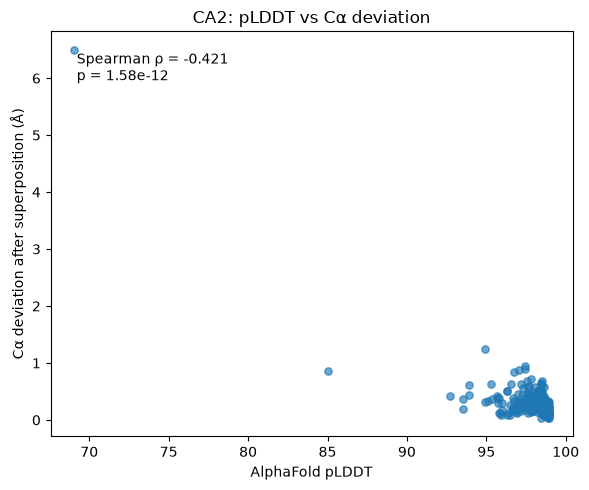

Saved: CA2_plddt_vs_deviation.png


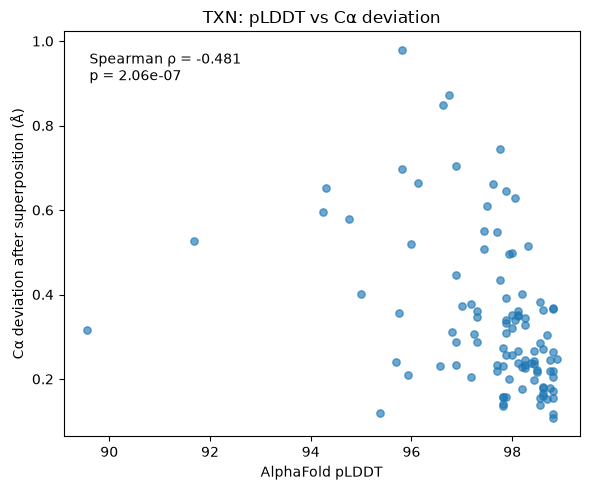

Saved: TXN_plddt_vs_deviation.png


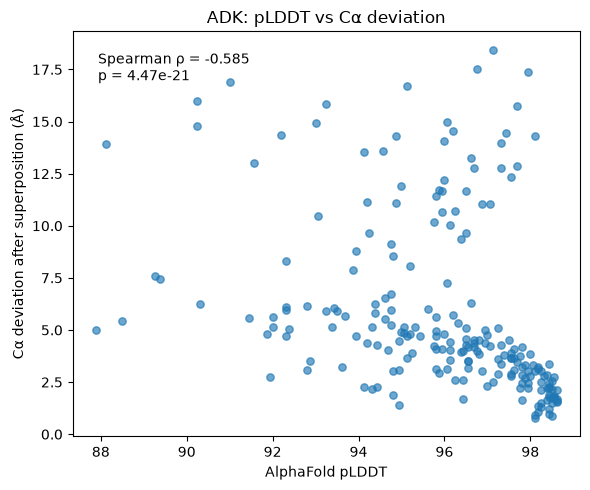

Saved: ADK_plddt_vs_deviation.png


In [42]:
correlation_lookup = (
    correlation_summary_df
    .set_index("protein")
)

for protein, df in structure_dfs.items():

    rho = correlation_lookup.loc[
        protein,
        "spearman_rho"
    ]

    p_value = correlation_lookup.loc[
        protein,
        "p_value"
    ]

    plt.figure(figsize=(6, 5))

    plt.scatter(
        df["plddt"],
        df["ca_deviation"],
        alpha=0.65,
        s=28
    )

    plt.xlabel("AlphaFold pLDDT")
    plt.ylabel("Cα deviation after superposition (Å)")

    plt.title(
        f"{protein}: pLDDT vs Cα deviation"
    )

    plt.text(
        0.05,
        0.95,
        f"Spearman ρ = {rho:.3f}\n"
        f"p = {p_value:.2e}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.tight_layout()

    output_file = (
        FIGURE_DIR /
        f"{protein}_plddt_vs_deviation.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file.name)

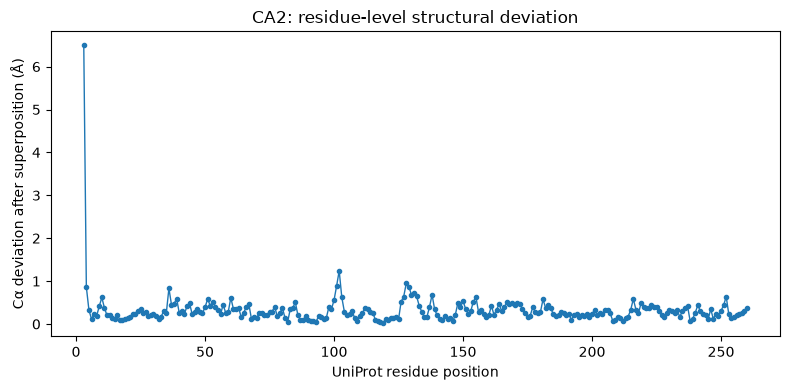

Saved: CA2_deviation_by_position.png


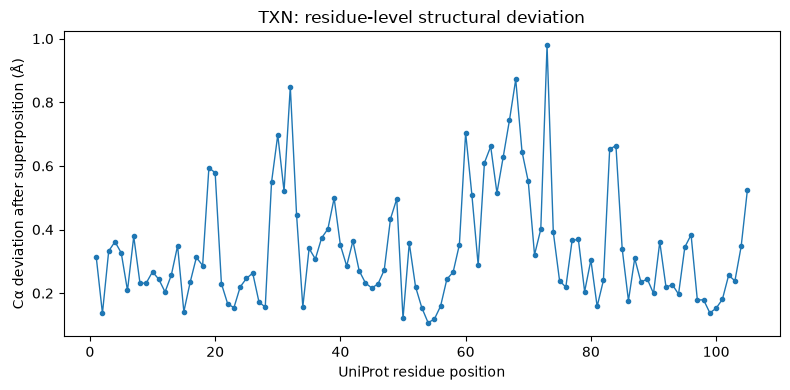

Saved: TXN_deviation_by_position.png


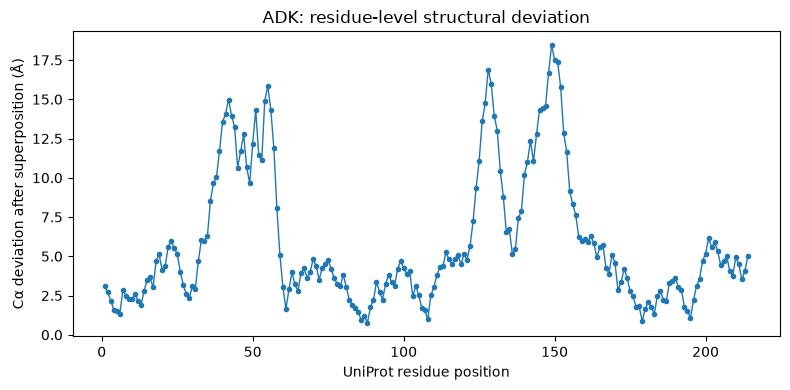

Saved: ADK_deviation_by_position.png


In [43]:
for protein, df in structure_dfs.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        df["uniprot_position"],
        df["ca_deviation"],
        marker="o",
        markersize=3,
        linewidth=1
    )

    plt.xlabel("UniProt residue position")
    plt.ylabel("Cα deviation after superposition (Å)")
    plt.title(
        f"{protein}: residue-level structural deviation"
    )

    plt.tight_layout()

    output_file = (
        FIGURE_DIR /
        f"{protein}_deviation_by_position.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file.name)

In [44]:
outlier_results = []

for protein, df in structure_dfs.items():

    deviation_threshold = (
        df["ca_deviation"].quantile(0.90)
    )

    outliers = df[
        (df["plddt"] >= 90) &
        (df["ca_deviation"] >= deviation_threshold)
    ].copy()

    outliers["protein"] = protein
    outliers["deviation_threshold"] = (
        deviation_threshold
    )

    outlier_results.append(outliers)

    print(
        protein,
        "| 90th percentile deviation =",
        round(deviation_threshold, 3),
        "Å",
        "| high-confidence/high-deviation residues =",
        len(outliers)
    )

CA2 | 90th percentile deviation = 0.511 Å | high-confidence/high-deviation residues = 24
TXN | 90th percentile deviation = 0.621 Å | high-confidence/high-deviation residues = 11
ADK | 90th percentile deviation = 13.17 Å | high-confidence/high-deviation residues = 21


In [45]:
high_confidence_outliers_df = pd.concat(
    outlier_results,
    ignore_index=True
)

display(
    high_confidence_outliers_df[
        [
            "protein",
            "uniprot_position",
            "uniprot_aa",
            "plddt",
            "ca_deviation",
            "deviation_threshold"
        ]
    ]
    .sort_values(
        ["protein", "ca_deviation"],
        ascending=[True, False]
    )
)

,protein,uniprot_position,uniprot_aa,plddt,ca_deviation,deviation_threshold
52,ADK,149,T,97.12,18.444037,13.169922
53,ADK,150,G,96.75,17.524051,13.169922
54,ADK,151,E,97.94,17.374691,13.169922
46,ADK,128,P,91.00,16.880582,13.169922
51,ADK,148,V,95.12,16.705143,13.169922
47,ADK,129,S,90.25,15.989618,13.169922
42,ADK,55,A,93.25,15.845950,13.169922
55,ADK,152,E,97.69,15.768256,13.169922
37,ADK,42,G,96.06,14.983146,13.169922
41,ADK,54,D,93.00,14.918975,13.169922


In [46]:
outlier_file = (
    TABLE_DIR /
    "high_confidence_high_deviation_residues.csv"
)

high_confidence_outliers_df.to_csv(
    outlier_file,
    index=False
)

print("Saved:", outlier_file)
print("Exists:", outlier_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\high_confidence_high_deviation_residues.csv
Exists: True


In [48]:
def assign_adk_domain(position):
    if 30 <= position <= 67:
        return "NMP"
    elif 118 <= position <= 160:
        return "LID"
    else:
        return "CORE"

In [49]:
adk_df = structure_dfs["ADK"].copy()

adk_df["domain"] = (
    adk_df["uniprot_position"]
    .apply(assign_adk_domain)
)

display(
    adk_df[
        [
            "uniprot_position",
            "plddt",
            "ca_deviation",
            "domain"
        ]
    ].head(20)
)

,uniprot_position,plddt,ca_deviation,domain
0,1,94.94,3.089118,CORE
1,2,97.88,2.699017,CORE
2,3,98.50,2.169223,CORE
3,4,98.62,1.600614,CORE
4,5,98.50,1.494184,CORE
5,6,98.19,1.346598,CORE
6,7,97.56,2.867066,CORE
7,8,97.12,2.499525,CORE
8,9,94.44,2.270121,CORE
9,10,94.12,2.261916,CORE


In [50]:
adk_domain_summary = (
    adk_df
    .groupby("domain")
    .agg(
        n_residues=("uniprot_position", "count"),
        mean_deviation=("ca_deviation", "mean"),
        median_deviation=("ca_deviation", "median"),
        max_deviation=("ca_deviation", "max"),
        mean_plddt=("plddt", "mean")
    )
    .reset_index()
)

display(adk_domain_summary)

,domain,n_residues,mean_deviation,median_deviation,max_deviation,mean_plddt
0,CORE,133,3.419530,3.369512,6.270688,96.549023
1,LID,43,10.555471,10.451518,18.444037,94.100465
2,NMP,38,8.927971,9.846015,15.845950,95.761316


In [51]:
adk_threshold = (
    adk_df["ca_deviation"]
    .quantile(0.90)
)

adk_high_dev = adk_df[
    adk_df["ca_deviation"] >= adk_threshold
].copy()

domain_outlier_counts = (
    adk_high_dev["domain"]
    .value_counts()
)

print(
    "ADK 90th percentile threshold:",
    round(adk_threshold, 3),
    "Å"
)

display(domain_outlier_counts)

ADK 90th percentile threshold: 13.17 Å


domain
LID    13
NMP     9
Name: count, dtype: int64

In [52]:
adk_domain_summary_file = (
    TABLE_DIR /
    "ADK_domain_summary.csv"
)

adk_domain_summary.to_csv(
    adk_domain_summary_file,
    index=False
)

print("Saved:", adk_domain_summary_file)
print("Exists:", adk_domain_summary_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\ADK_domain_summary.csv
Exists: True


In [53]:
adk_high_dev_file = (
    TABLE_DIR /
    "ADK_top10_percent_deviation_residues.csv"
)

adk_high_dev.to_csv(
    adk_high_dev_file,
    index=False
)

print("Saved:", adk_high_dev_file)
print("Exists:", adk_high_dev_file.exists())

Saved: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis\results\tables\ADK_top10_percent_deviation_residues.csv
Exists: True


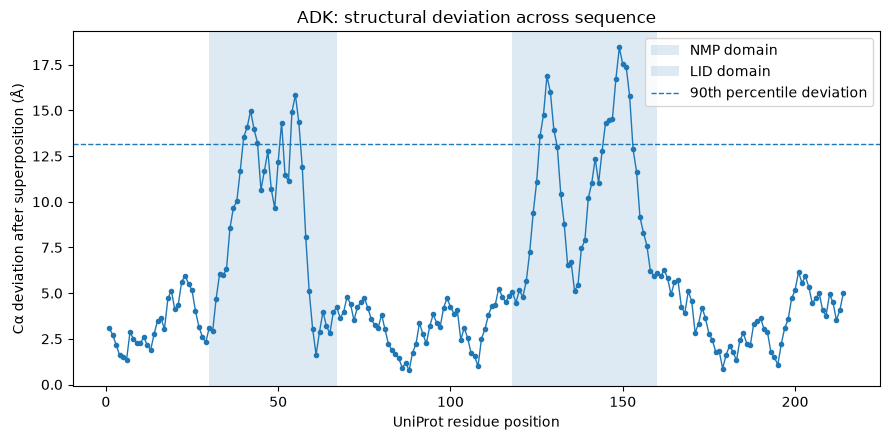

Saved: ADK_deviation_by_domain.png


In [54]:
plt.figure(figsize=(9, 4.5))

plt.plot(
    adk_df["uniprot_position"],
    adk_df["ca_deviation"],
    marker="o",
    markersize=3,
    linewidth=1
)

plt.axvspan(
    30,
    67,
    alpha=0.15,
    label="NMP domain"
)

plt.axvspan(
    118,
    160,
    alpha=0.15,
    label="LID domain"
)

plt.axhline(
    adk_threshold,
    linestyle="--",
    linewidth=1,
    label="90th percentile deviation"
)

plt.xlabel("UniProt residue position")
plt.ylabel("Cα deviation after superposition (Å)")
plt.title("ADK: structural deviation across sequence")

plt.legend()
plt.tight_layout()

output_file = (
    FIGURE_DIR /
    "ADK_deviation_by_domain.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file.name)

In [55]:
rmsd_summary_df

,protein,uniprot_id,paired_residues,raw_rmsd,aligned_ca_rmsd,rotation_determinant
0,CA2,P00918,258,33.124188,0.531232,1.0
1,TXN,P10599,105,47.042479,0.384446,1.0
2,ADK,P69441,214,23.536265,7.200427,1.0


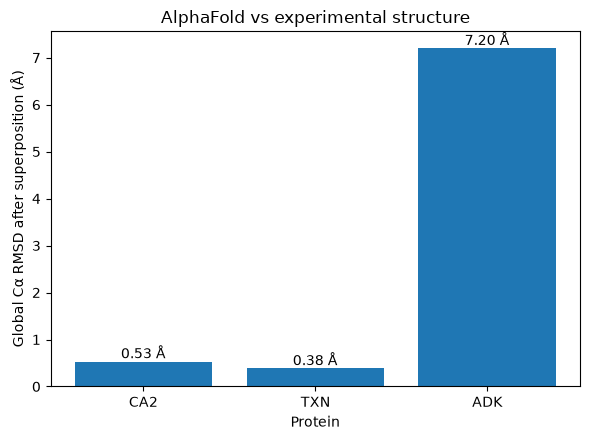

Saved: global_rmsd_summary.png


In [56]:
plt.figure(figsize=(6, 4.5))

bars = plt.bar(
    rmsd_summary_df["protein"],
    rmsd_summary_df["aligned_ca_rmsd"]
)

plt.xlabel("Protein")
plt.ylabel("Global Cα RMSD after superposition (Å)")
plt.title("AlphaFold vs experimental structure")

for bar, value in zip(
    bars,
    rmsd_summary_df["aligned_ca_rmsd"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} Å",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

output_file = (
    FIGURE_DIR /
    "global_rmsd_summary.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file.name)

Results summary
After residue mapping and Cα-based Kabsch superposition, CA2 and TXN showed close structural agreement between the AlphaFold models and the selected experimental structures, with global Cα RMSDs of 0.531 Å and 0.384 Å, respectively. In contrast, ADK showed a substantially larger global Cα RMSD of 7.20 Å.
At the residue level, pLDDT was negatively associated with Cα deviation in all three proteins. Spearman correlations were −0.421 for CA2, −0.481 for TXN, and −0.585 for ADK. Thus, residues with higher AlphaFold confidence generally tended to show smaller deviations from the corresponding experimental structures.
However, high pLDDT did not guarantee close agreement with a particular experimental conformation. ADK contained several residues with pLDDT above 90 but Cα deviations greater than 10 Å; for example, residue 149 had a pLDDT of approximately 97 and a deviation of approximately 18.4 Å.
The structural disagreement in ADK was not uniformly distributed across the sequence. The CORE region had a median deviation of approximately 3.37 Å, whereas the NMP and LID regions had median deviations of approximately 9.85 Å and 10.45 Å, respectively. All residues in the top 10% of the ADK deviation distribution were located within the NMP or LID regions.

Interpretation
These results suggest that AlphaFold pLDDT contains useful residue-level information: within each protein, higher-confidence residues generally tend to agree more closely with the selected experimental structure.
However, pLDDT should not be interpreted as a direct measure of agreement with every possible experimental conformation. ADK provides an important example: despite generally high pLDDT values, the AlphaFold model shows large positional differences from the selected 4AKE structure in specific regions.
The concentration of large deviations in the NMP and LID regions suggests that the high global RMSD of ADK reflects a structured, domain-level conformational difference rather than random residue-level prediction errors. Comparison with additional experimental conformational states would be required before determining which state the AlphaFold model most closely resembles.

Limitations
This study contains only three proteins, so the results should be interpreted as a small exploratory structural bioinformatics analysis rather than a general benchmark of AlphaFold accuracy.
Each AlphaFold model was compared with one selected experimental PDB structure. Experimental protein structures can represent particular ligand-binding, oxidation, crystallization, or conformational states; therefore, structural disagreement does not necessarily imply prediction error.
Residue-level observations are also not fully independent because neighboring residues are connected in sequence and three-dimensional structure. Therefore, the nominal Spearman p-values should be interpreted cautiously, with greater emphasis placed on the direction and magnitude of the correlations.
Finally, the current analysis uses Cα-based rigid-body superposition. Although this provides a useful measure of backbone-level disagreement, it does not evaluate side-chain geometry or fully describe domain motions and local structural changes.

In [57]:
from pathlib import Path

expected_outputs = [
    PROJECT_ROOT / "results" / "tables" / "mapping_summary.csv",
    PROJECT_ROOT / "results" / "tables" / "rmsd_summary.csv",
    PROJECT_ROOT / "results" / "tables" / "correlation_summary.csv",
    PROJECT_ROOT / "results" / "tables" / "high_confidence_high_deviation_residues.csv",
    PROJECT_ROOT / "results" / "tables" / "ADK_domain_summary.csv",

    PROJECT_ROOT / "results" / "figures" / "global_rmsd_summary.png",
    PROJECT_ROOT / "results" / "figures" / "CA2_plddt_vs_deviation.png",
    PROJECT_ROOT / "results" / "figures" / "TXN_plddt_vs_deviation.png",
    PROJECT_ROOT / "results" / "figures" / "ADK_plddt_vs_deviation.png",
    PROJECT_ROOT / "results" / "figures" / "ADK_deviation_by_domain.png",

    PROJECT_ROOT / "data" / "processed" / "CA2_structure_comparison.csv",
    PROJECT_ROOT / "data" / "processed" / "TXN_structure_comparison.csv",
    PROJECT_ROOT / "data" / "processed" / "ADK_structure_comparison.csv",
]

for path in expected_outputs:
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:8} {path.relative_to(PROJECT_ROOT)}")

OK       results\tables\mapping_summary.csv
OK       results\tables\rmsd_summary.csv
OK       results\tables\correlation_summary.csv
OK       results\tables\high_confidence_high_deviation_residues.csv
OK       results\tables\ADK_domain_summary.csv
OK       results\figures\global_rmsd_summary.png
OK       results\figures\CA2_plddt_vs_deviation.png
OK       results\figures\TXN_plddt_vs_deviation.png
OK       results\figures\ADK_plddt_vs_deviation.png
OK       results\figures\ADK_deviation_by_domain.png
OK       data\processed\CA2_structure_comparison.csv
OK       data\processed\TXN_structure_comparison.csv
OK       data\processed\ADK_structure_comparison.csv
